In [1]:
import numpy as np
from array import *
import matplotlib.pyplot as plt
import os
import time
import glob
import dunestyle.matplotlib as dunestyle
import pandas as pd

DUNE plot style enabled


/home/leoperes/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Specify the folder where the files are located
folder_path = 'plots/20260512_101630/'

# Use glob to find all files matching the pattern in the specified folder
pattern = os.path.join(folder_path, 'limits*.dat')

# Get all files matching the pattern
files = sorted(glob.glob(pattern))

print(f"Found {len(files)} files: {files}")
# Move the first 4 files to the last place
if len(files) > 4:
    files = files[4:] + files[:4]

# Initialize a list of 5 empty lists, one for each line
limits = [[] for _ in range(5)]

# Read each file
for file in files:
    with open(file, 'r') as f:
        # Read each line and store it in the appropriate list
        for i, line in enumerate(f.readlines()):
            number = float(line.strip())  # Convert the line to an integer
            limits[i].append(number)  # Add the number to the appropriate list


Found 12 files: ['plots/20260512_101630/limits_b10_m05.dat', 'plots/20260512_101630/limits_b10_m10.dat', 'plots/20260512_101630/limits_b10_m20.dat', 'plots/20260512_101630/limits_b10_m40.dat', 'plots/20260512_101630/limits_b1p1_m05.dat', 'plots/20260512_101630/limits_b1p1_m10.dat', 'plots/20260512_101630/limits_b1p1_m20.dat', 'plots/20260512_101630/limits_b1p1_m40.dat', 'plots/20260512_101630/limits_b1p5_m05.dat', 'plots/20260512_101630/limits_b1p5_m10.dat', 'plots/20260512_101630/limits_b1p5_m20.dat', 'plots/20260512_101630/limits_b1p5_m40.dat']


In [3]:
# Print each list of numbers
for i, values in enumerate(limits, start=1):
    print(f"Numbers from line {i} across all files: {values}")

Numbers from line 1 across all files: [1.368868868868869e-06, 1.7785785785785786e-06, 2.5615615615615616e-06, 4.423923923923923e-06, 3.1021021021021017e-07, 4.4234234234234234e-07, 7.086086086086087e-07, 1.3618618618618618e-06, 1.776076076076076e-07, 3.3048048048048047e-07, 5.201201201201201e-07, 1.3099099099099099e-06]
Numbers from line 2 across all files: [1.5965965965965967e-06, 2.038838838838839e-06, 3.01001001001001e-06, 5.195195195195194e-06, 3.6346346346346346e-07, 5.144144144144143e-07, 8.246246246246247e-07, 1.5860860860860862e-06, 2.06016016016016e-07, 3.822822822822823e-07, 6.099099099099099e-07, 1.5180180180180181e-06]
Numbers from line 3 across all files: [1.9399399399399397e-06, 2.502102102102102e-06, 3.65065065065065e-06, 6.3003003003003e-06, 4.37037037037037e-07, 6.207207207207207e-07, 9.976976976976979e-07, 1.904904904904905e-06, 2.4776776776776776e-07, 4.5285285285285286e-07, 7.283283283283283e-07, 1.8249249249249251e-06]
Numbers from line 4 across all files: [2.38838

In [4]:
limits

[[1.368868868868869e-06,
  1.7785785785785786e-06,
  2.5615615615615616e-06,
  4.423923923923923e-06,
  3.1021021021021017e-07,
  4.4234234234234234e-07,
  7.086086086086087e-07,
  1.3618618618618618e-06,
  1.776076076076076e-07,
  3.3048048048048047e-07,
  5.201201201201201e-07,
  1.3099099099099099e-06],
 [1.5965965965965967e-06,
  2.038838838838839e-06,
  3.01001001001001e-06,
  5.195195195195194e-06,
  3.6346346346346346e-07,
  5.144144144144143e-07,
  8.246246246246247e-07,
  1.5860860860860862e-06,
  2.06016016016016e-07,
  3.822822822822823e-07,
  6.099099099099099e-07,
  1.5180180180180181e-06],
 [1.9399399399399397e-06,
  2.502102102102102e-06,
  3.65065065065065e-06,
  6.3003003003003e-06,
  4.37037037037037e-07,
  6.207207207207207e-07,
  9.976976976976979e-07,
  1.904904904904905e-06,
  2.4776776776776776e-07,
  4.5285285285285286e-07,
  7.283283283283283e-07,
  1.8249249249249251e-06],
 [2.3883883883883884e-06,
  3.085085085085085e-06,
  4.483483483483483e-06,
  7.71621621

In [5]:

# lighter DM mass
MB = np.array([5,10,20,40])
# gamma
gam = np.array([1.1, 1.5, 10])
# Heavy DM mass = Lighter DM mass * gamma
MA = np.reshape(np.multiply.outer(gam,MB),12)
print(MA)
PhenPaperSensitivity =  [6.12877527e-07, 8.28514808e-07, 1.23738536e-06, 2.19586539e-06,
 2.75543123e-07, 3.90073889e-07, 6.29320177e-07, 1.21236806e-06,
 1.54204697e-07, 2.72382985e-07, 4.46945198e-07, 1.04557268e-06]
#[6.12877527e-07, 8.28514808e-07, 1.23738536e-06, 2.19586539e-06, 2.75543123e-07, 3.90073889e-07, 6.29320177e-07, 1.21236806e-06, 1.54204697e-07, 2.72382985e-07, 4.46945198e-07, 1.04557268e-06]

[  5.5  11.   22.   44.    7.5  15.   30.   60.   50.  100.  200.  400. ]


In [6]:

################################################################
sk_b1p5 = np.array(pd.read_csv('sk_b1p5.csv', header=None))[:,1]
sk_b10 = np.array(pd.read_csv('sk_b10.csv', header=None))[:,1]
################################################################    

In [7]:

# ===============================================
# LZ: Spin-dependent proton cross section Limits
# ===============================================
# A -> m_\psi
# Taken from LZ collaboration paper: https://journals.aps.org/prl/pdf/10.1103/4dyc-z8zf
# https://www.hepdata.net/record/155182 SDp cross section limits

# m_A (GeV), sigma_SD_p (cm^2)
LZ_limits = np.array([[9.0,3.5723335281428886e-40],
                     [11.0,1.0842762041258605e-40],
                     [13.0,4.888469407408583e-41],
                     [16.0,2.610728651858171e-41],
                     [17.0,2.2629149586047365e-41],
                     [19.0,1.7921748796738665e-41],
                     [21.0,1.5081548807504159e-41],
                     [23.0,1.300824634834846e-41],
                     [26.0,1.1962902159600065e-41],
                     [29.0,1.0607607539011196e-41],
                     [32.0,1.0231639397447364e-41],
                     [36.0,9.819552044357828e-42],
                     [40.0,9.817724507739145e-42],
                     [43.0,9.923586965138234e-42],
                     [46.0,1.0333162882471695e-41],
                     [65.0,1.1657011697765395e-41],
                     [91.0,1.4625342161354974e-41],
                     [129.0,2.1833339459138402e-41],
                     [182.0,3.2120995713254245e-41],
                     [256.0,4.441687124827767e-41],
                     [361.0,6.237697783203983e-41],
                     [508.0,9.018219520303284e-41],
                     [1008.0,1.7809026325700012e-40],
                     [2000.0,3.5571455193816383e-40],
                     [5000.0,8.575067963308816e-40],
                     [10000.0,1.755952792252412e-39]])

mA_array      = LZ_limits[:, 0]   # heavy DM mass m_A in GeV
sigma_lim_LZ  = LZ_limits[:, 1]   # LZ limit σ_lim(m_A) in cm^2


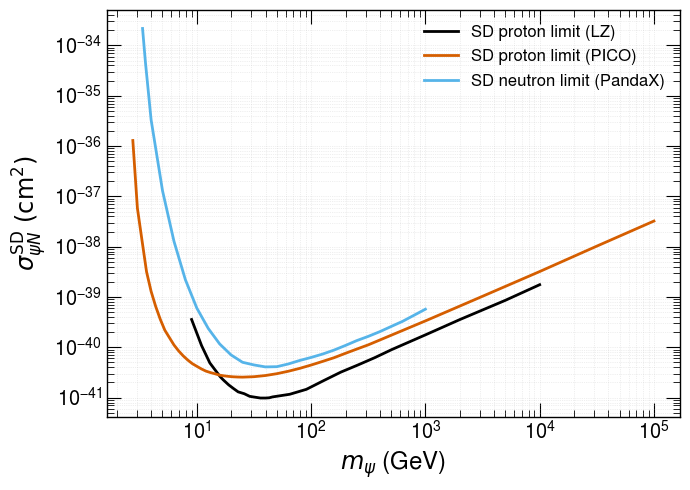

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from io import StringIO

# =====================================================
# 1) Helper to read an XML spin-dependent limit file
#    (SD-p-2019.xml or SD-n-2019.xml)
# =====================================================

def read_sd_xml(filename):
    """
    Read a spin-dependent DD limit XML like SD-p-2019.xml
    and return (mass_array, sigma_limit_array).
    """
    tree = ET.parse(filename)
    root = tree.getroot()

    for child in root:
        if child.tag != "data-values":
            continue

        txt = (child.text.replace("[", "")
                         .replace("]", "")
                         .replace("{", "")
                         .replace("}", "")
                         .replace(";", " "))

        data = np.genfromtxt(StringIO(txt))
        # data is [m1, s1, m2, s2, ...]
        masses = data[::2]
        limits = data[1::2]
        return masses, limits

    raise RuntimeError(f"No <data-values> block found in {filename}")

# =====================================================
# 2) Read proton and neutron SD limits
# =====================================================

file_p = "SD-p-2019.xml"  # spin-dependent proton
file_n = "SD-n-2019.xml"  # spin-dependent neutron

m_p, sig_p = read_sd_xml(file_p)
m_n, sig_n = read_sd_xml(file_n)

# =====================================================
# 3) Plot DD limits
# =====================================================

plt.figure(figsize=(7,5))

#LZ Proton SD limits

plt.loglog( LZ_limits[:,0],LZ_limits[:,1], label="SD proton limit (LZ)", lw=2)

# Proton SD limit
plt.loglog(m_p, sig_p, label="SD proton limit (PICO)", lw=2)

# Neutron SD limit
plt.loglog(m_n, sig_n, label="SD neutron limit (PandaX)", lw=2)

plt.xlabel(r"$m_\psi$ (GeV)")
plt.ylabel(r"$\sigma_{\psi N}^{\rm SD}\ \mathrm{(cm^2)}$")
#plt.title("Spin-dependent direct detection limits (2019)")
plt.grid(which="both", linestyle=":", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
# If your LZ file is SD-p:
gZ4_LZ = sigma_lim_LZ /1e-35
gZ4_PICO = sig_p / 1e-35

In [10]:
from matplotlib.ticker import FixedLocator, NullLocator, ScalarFormatter

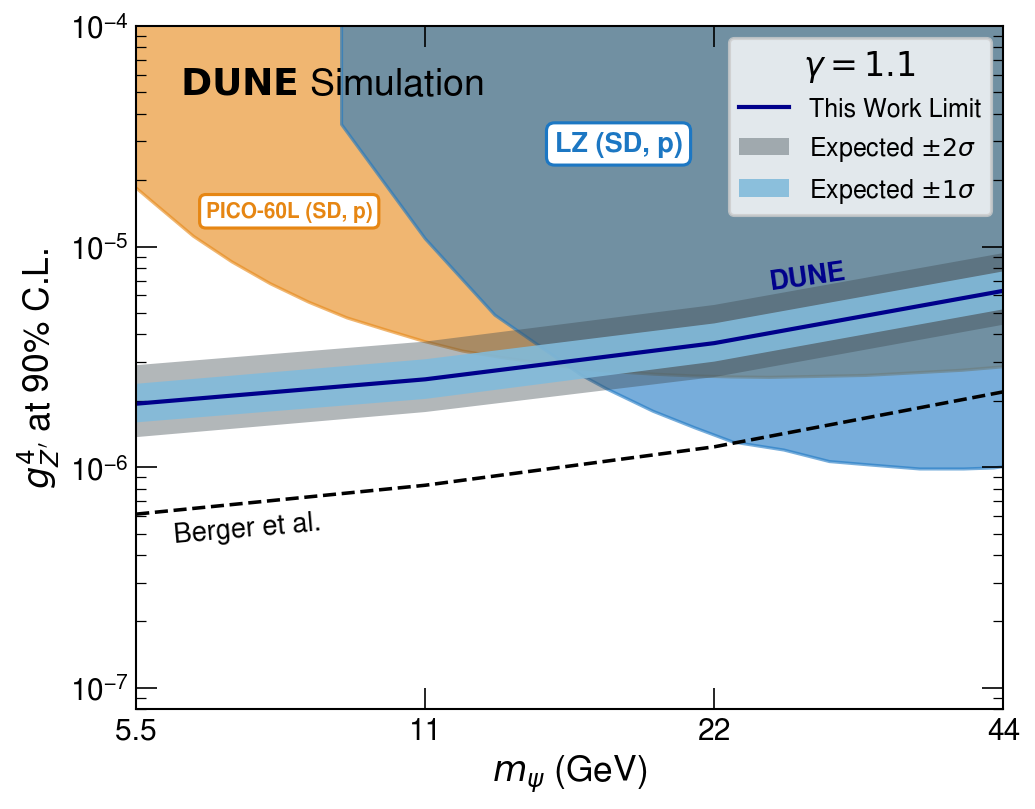

In [11]:

################################################################
#                 PLOT FIGURE          gamma = 1.1             #
################################################################

fig, ax = plt.subplots(figsize=(7.0, 5.5), dpi=150)

# Colors
c_pheno = "#4D4D4D"
c_pico = "#E68613"
c_lz = "#1C77C3"
sig2 = "#3F4B52"
sig1 = "#82BBDB"

#plt.fill_between(m_p, gZ4_PICO, 1, alpha=0.3,label = 'PICO 60L, p', color = 'darkgreen')
# Lines
line_this, = ax.plot(MA[0:4], limits[2][0:4], lw=2., color='darkblue',ls='-', label = 'This Work Limit')
line_pheno, = ax.plot(MA[0:4], PhenPaperSensitivity[0:4], '--', lw=1.7, color='black')
#line_pico,  =
plt.fill_between(m_p, gZ4_PICO,1., color=c_pico, alpha = 0.6)
#line_lz,    = 
plt.fill_between(mA_array, gZ4_LZ,1., color=c_lz, alpha = 0.6)

# Bands
band_2s = ax.fill_between(
    MA[0:4], limits[0][0:4], limits[4][0:4],
    alpha=0.4, label=r'Expected $\pm 2\sigma$',color=sig2,ec=None
)
band_1s = ax.fill_between(
    MA[0:4], limits[1][0:4], limits[3][0:4],
    alpha=0.90, label=r'Expected $\pm 1\sigma$', color=sig1, ec=None
)

# ---- Axes ----
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(8e-8, 1e-4)
ax.set_xlim(5.5, 44)

ax.set_xlabel(r'$m_\psi$ (GeV)', fontsize=17)
ax.set_ylabel(r'$g_{Z^\prime}^4$ at 90% C.L.', fontsize=17)

# ---- Curve labels INSIDE plot ----
#ax.text(12, limits[2][1] * 1.10, "This Work", color=c_this, fontsize=14)
ax.text(25, PhenPaperSensitivity[0] * 10.5, "DUNE", color='darkblue', fontsize=13, rotation=8, fontweight='bold')
ax.text(6.0, PhenPaperSensitivity[0] * 0.75, "Berger et al.", color='black', fontsize=13, rotation=5)
ax.text(6.5, gZ4_PICO[10] * 1.6, "PICO-60L (SD, p)", color=c_pico, fontsize=10,  bbox=dict(facecolor='white', edgecolor=c_pico, boxstyle='round'), fontweight='bold')
ax.text(15, gZ4_LZ[1]*2.5, "LZ (SD, p)", color=c_lz, fontsize=13,   bbox=dict(facecolor='white', edgecolor=c_lz, boxstyle='round'), fontweight='bold')

# disable ALL minor ticks on x axis
ax.xaxis.set_minor_locator(NullLocator())

# prevent Matplotlib from adding extra log ticks
ax.xaxis.set_major_locator(FixedLocator(MA[0:4]))

# avoid scientific notation on axis
ax.get_xaxis().set_major_formatter(ScalarFormatter())

ax.set_xticks(MA[0:4])
ax.set_xticklabels(['5.5','11','22','44'])

dunestyle.Simulation()
# ---- Legend only for bands ----
ax.legend(title = r'$\gamma = 1.1$', frameon=True, fontsize=12, loc="upper right", title_fontsize=16)

plt.tight_layout()
plt.savefig("plot_gamma1p1_final.pdf")
plt.show()


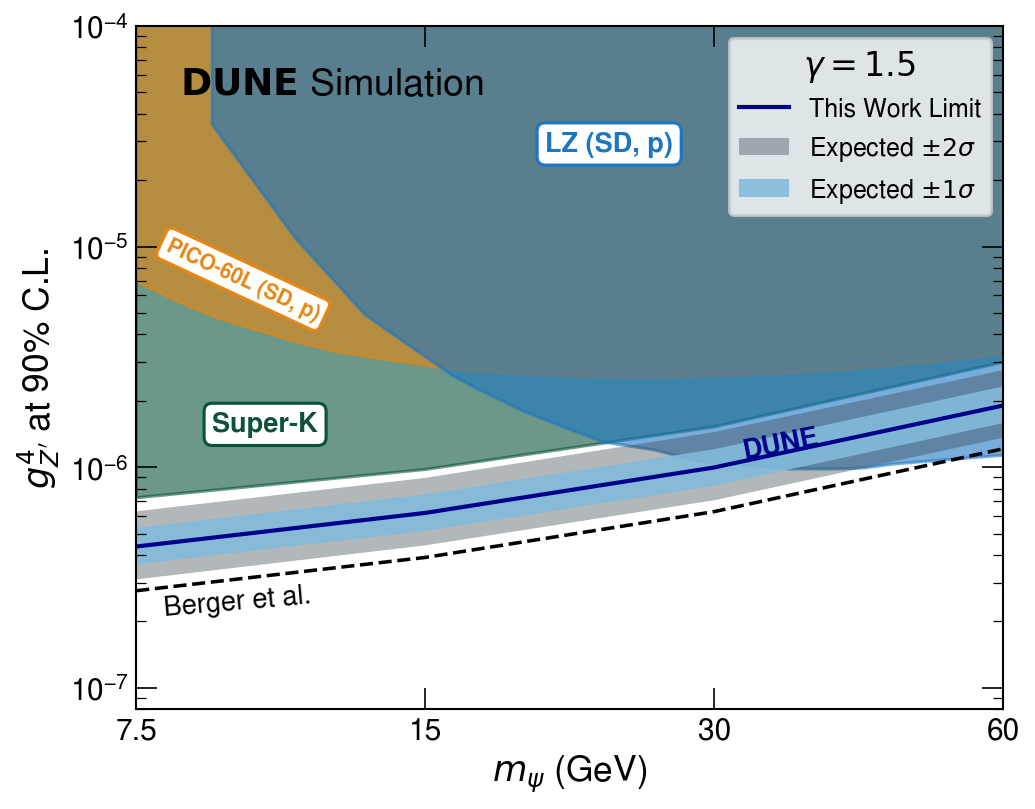

In [12]:

################################################################
#                 PLOT FIGURE          gamma = 1.5             #
################################################################
fig, ax = plt.subplots(figsize=(7.0, 5.5), dpi=150)

# Colors
c_pheno = "#4D4D4D"
c_pico = "#E68613"
c_lz = "#1C77C3"
sig2 = "#3F4B52"
sig1 = "#82BBDB"
sk = "#0A5337"

#plt.fill_between(m_p, gZ4_PICO, 1, alpha=0.3,label = 'PICO 60L, p', color = 'darkgreen')
# Lines
line_this, = ax.plot(MA[4:8], limits[2][4:8], lw=2., color='darkblue',ls='-', label = 'This Work Limit')
line_pheno, = ax.plot(MA[4:8], PhenPaperSensitivity[4:8], '--', lw=1.7, color='black')

plt.fill_between(MA[4:8], sk_b1p5,1., color=sk, alpha = 0.6)
plt.fill_between(m_p, gZ4_PICO,1., color=c_pico, alpha = 0.6)

plt.fill_between(mA_array, gZ4_LZ,1., color=c_lz, alpha = 0.6)



# Bands
band_2s = ax.fill_between(
    MA[4:8], limits[0][4:8], limits[4][4:8],
    alpha=0.4, label=r'Expected $\pm 2\sigma$',color=sig2,ec=None
)
band_1s = ax.fill_between(
    MA[4:8], limits[1][4:8], limits[3][4:8],
    alpha=0.90, label=r'Expected $\pm 1\sigma$', color=sig1, ec=None
)


# ---- Axes ----
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(8e-8, 1e-4)
ax.set_xlim(7.5, 60)

ax.set_xlabel(r'$m_\psi$ (GeV)', fontsize=17)
ax.set_ylabel(r'$g_{Z^\prime}^4$ at 90% C.L.', fontsize=17)

# ---- Curve labels INSIDE plot ----
#ax.text(12, limits[2][1] * 1.10, "This Work", color=c_this, fontsize=14)
ax.text(32, PhenPaperSensitivity[0] * 1.8, "DUNE", color='darkblue', fontsize=13, rotation=11, fontweight='bold')
ax.text(8.0, PhenPaperSensitivity[0] * 0.35, "Berger et al.", color='black', fontsize=13, rotation=5)
ax.text(9.0, sk_b1p5[0] * 2., "Super-K", color=sk, fontsize=13, bbox=dict(facecolor='white', edgecolor=sk, boxstyle='round'), fontweight='bold')
ax.text(8, gZ4_PICO[10]*0.55 , "PICO-60L (SD, p)", color=c_pico, fontsize=10,  bbox=dict(facecolor='white', edgecolor=c_pico, boxstyle='round'), fontweight='bold',rotation=-25)
ax.text(20, gZ4_LZ[1]*2.5, "LZ (SD, p)", color=c_lz, fontsize=13,   bbox=dict(facecolor='white', edgecolor=c_lz, boxstyle='round'), fontweight='bold')

# disable ALL minor ticks on x axis
ax.xaxis.set_minor_locator(NullLocator())

# prevent Matplotlib from adding extra log ticks
ax.xaxis.set_major_locator(FixedLocator(MA[0:4]))

# avoid scientific notation on axis
ax.get_xaxis().set_major_formatter(ScalarFormatter())

ax.set_xticks(MA[4:8])
ax.set_xticklabels(['7.5','15','30','60'])

dunestyle.Simulation()
# ---- Legend only for bands ----
ax.legend(title = r'$\gamma = 1.5$', frameon=True, fontsize=12, loc="upper right", title_fontsize=16)

plt.tight_layout()
plt.savefig("plot_gamma1p5_final.pdf")
plt.show()




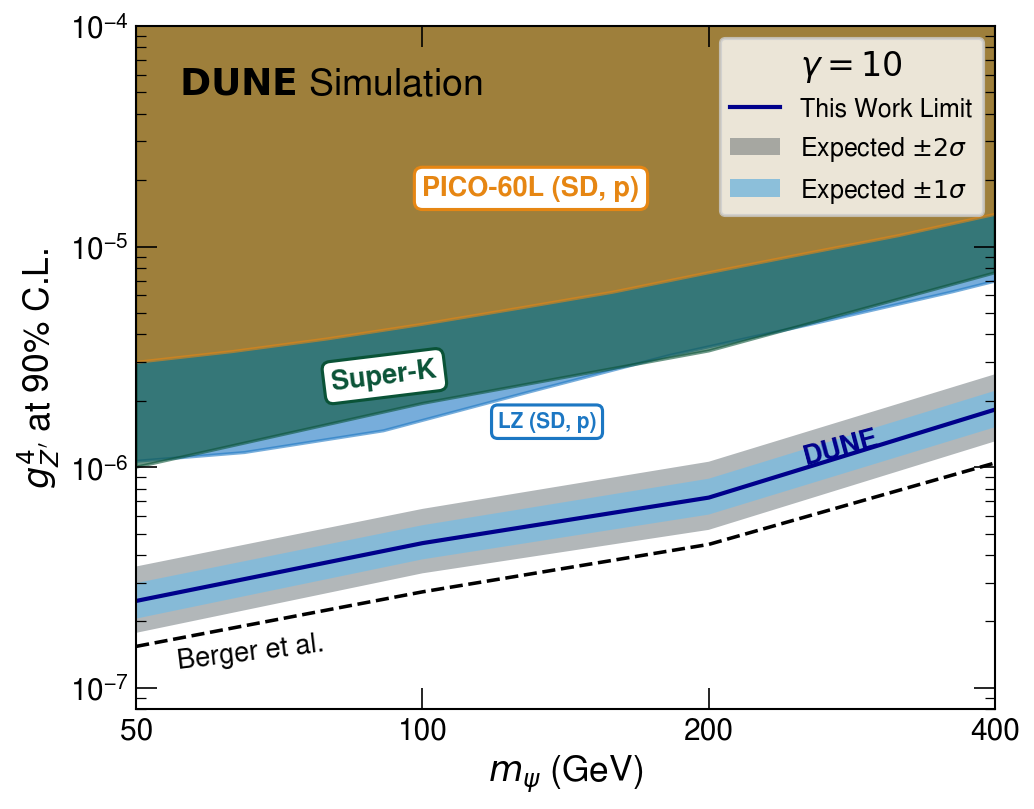

In [13]:
################################################################
#                 PLOT FIGURE          gamma = 10              #
################################################################
fig, ax = plt.subplots(figsize=(7.0, 5.5), dpi=150)

# Colors
c_pheno = "#4D4D4D"
c_pico = "#E68613"
c_lz = "#1C77C3"
sig2 = "#3F4B52"
sig1 = "#82BBDB"
sk = "#0A5337"

#plt.fill_between(m_p, gZ4_PICO, 1, alpha=0.3,label = 'PICO 60L, p', color = 'darkgreen')
# Lines
line_this, = ax.plot(MA[8:12], limits[2][8:12], lw=2., color='darkblue',ls='-', label = 'This Work Limit')
line_pheno, = ax.plot(MA[8:12], PhenPaperSensitivity[8:12], '--', lw=1.7, color='black')

plt.fill_between(mA_array, gZ4_LZ,1., color=c_lz, alpha = 0.6)
plt.fill_between(MA[8:12], sk_b10,1., color=sk, alpha = 0.6)
plt.fill_between(m_p, gZ4_PICO,1., color=c_pico, alpha = 0.6)





# Bands
band_2s = ax.fill_between(
    MA[8:12], limits[0][8:12], limits[4][8:12],
    alpha=0.4, label=r'Expected $\pm 2\sigma$',color=sig2,ec=None
)
band_1s = ax.fill_between(
    MA[8:12], limits[1][8:12], limits[3][8:12],
    alpha=0.90, label=r'Expected $\pm 1\sigma$', color=sig1, ec=None
)


# ---- Axes ----
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(8e-8, 1e-4)
ax.set_xlim(50, 400)

ax.set_xlabel(r'$m_\psi$ (GeV)', fontsize=17)
ax.set_ylabel(r'$g_{Z^\prime}^4$ at 90% C.L.', fontsize=17)

# ---- Curve labels INSIDE plot ----
#ax.text(12, limits[2][1] * 1.10, "This Work", color=c_this, fontsize=14)
ax.text(250, PhenPaperSensitivity[0] * 1.7, "DUNE", color='darkblue', fontsize=13, rotation=15, fontweight='bold')
ax.text(55, PhenPaperSensitivity[0] * 0.2, "Berger et al.", color='black', fontsize=13, rotation=7)
ax.text(80, sk_b10[0] * 2.25, "Super-K", color=sk, fontsize=13, bbox=dict(facecolor='white', edgecolor=sk, boxstyle='round'), fontweight='bold',rotation=7)
ax.text(100, gZ4_PICO[10]*2., "PICO-60L (SD, p)", color=c_pico, fontsize=13,  bbox=dict(facecolor='white', edgecolor=c_pico, boxstyle='round'), fontweight='bold')
ax.text(120, gZ4_LZ[1]*0.14, "LZ (SD, p)", color=c_lz, fontsize=10,   bbox=dict(facecolor='white', edgecolor=c_lz, boxstyle='round'), fontweight='bold')

# disable ALL minor ticks on x axis
ax.xaxis.set_minor_locator(NullLocator())

# prevent Matplotlib from adding extra log ticks
ax.xaxis.set_major_locator(FixedLocator(MA[8:12]))

# avoid scientific notation on axis
ax.get_xaxis().set_major_formatter(ScalarFormatter())

ax.set_xticks(MA[8:12])
ax.set_xticklabels(['50','100','200','400'])

dunestyle.Simulation()
# ---- Legend only for bands ----
ax.legend(title = r'$\gamma = 10$', frameon=True, fontsize=12, loc="upper right", title_fontsize=16)

plt.tight_layout()
plt.savefig("plot_gamma10_final.pdf")
plt.show()




### Plots in Different Style


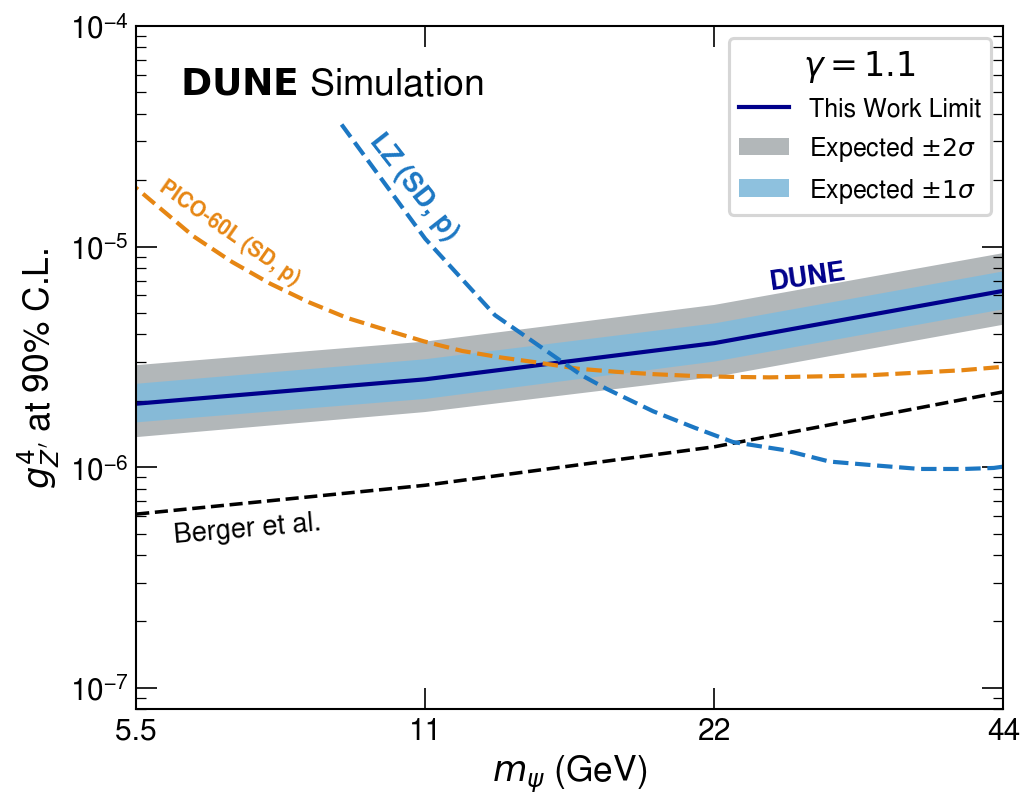

In [14]:

################################################################
#                 PLOT FIGURE          gamma = 1.1             #
################################################################

fig, ax = plt.subplots(figsize=(7.0, 5.5), dpi=150)

# Colors
c_pheno = "#4D4D4D"
c_pico = "#E68613"
c_lz = "#1C77C3"
sig2 = "#3F4B52"
sig1 = "#82BBDB"

#plt.fill_between(m_p, gZ4_PICO, 1, alpha=0.3,label = 'PICO 60L, p', color = 'darkgreen')
# Lines
line_this, = ax.plot(MA[0:4], limits[2][0:4], lw=2., color='darkblue',ls='-', label = 'This Work Limit')
line_pheno, = ax.plot(MA[0:4], PhenPaperSensitivity[0:4], '--', lw=1.7, color='black')
#line_pico,  =
ax.plot(m_p, gZ4_PICO, color=c_pico, ls='--', lw=2)
#line_lz,    = 
ax.plot(mA_array, gZ4_LZ,1., color=c_lz, ls='--', lw=2)

# Bands
band_2s = ax.fill_between(
    MA[0:4], limits[0][0:4], limits[4][0:4],
    alpha=0.4, label=r'Expected $\pm 2\sigma$',color=sig2,ec=None
)
band_1s = ax.fill_between(
    MA[0:4], limits[1][0:4], limits[3][0:4],
    alpha=0.90, label=r'Expected $\pm 1\sigma$', color=sig1, ec=None
)

# ---- Axes ----
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(8e-8, 1e-4)
ax.set_xlim(5.5, 44)

ax.set_xlabel(r'$m_\psi$ (GeV)', fontsize=17)
ax.set_ylabel(r'$g_{Z^\prime}^4$ at 90% C.L.', fontsize=17)

# ---- Curve labels INSIDE plot ----
#ax.text(12, limits[2][1] * 1.10, "This Work", color=c_this, fontsize=14)
ax.text(25, PhenPaperSensitivity[0] * 10.5, "DUNE", color='darkblue', fontsize=13, rotation=8, fontweight='bold')
ax.text(6.0, PhenPaperSensitivity[0] * 0.75, "Berger et al.", color='black', fontsize=13, rotation=5)
ax.text(5.75, gZ4_PICO[10] * 0.8, "PICO-60L (SD, p)", color=c_pico, fontsize=10, fontweight='bold', rotation = -35)
ax.text(9.5, gZ4_LZ[1]*1., "LZ (SD, p)", color=c_lz, fontsize=13,  fontweight='bold', rotation= -52)

# disable ALL minor ticks on x axis
ax.xaxis.set_minor_locator(NullLocator())

# prevent Matplotlib from adding extra log ticks
ax.xaxis.set_major_locator(FixedLocator(MA[0:4]))

# avoid scientific notation on axis
ax.get_xaxis().set_major_formatter(ScalarFormatter())

ax.set_xticks(MA[0:4])
ax.set_xticklabels(['5.5','11','22','44'])

dunestyle.Simulation()
# ---- Legend only for bands ----
ax.legend(title = r'$\gamma = 1.1$', frameon=True, fontsize=12, loc="upper right", title_fontsize=16)

plt.tight_layout()
plt.savefig("plot_gamma1p1_v2_final.pdf")
plt.show()


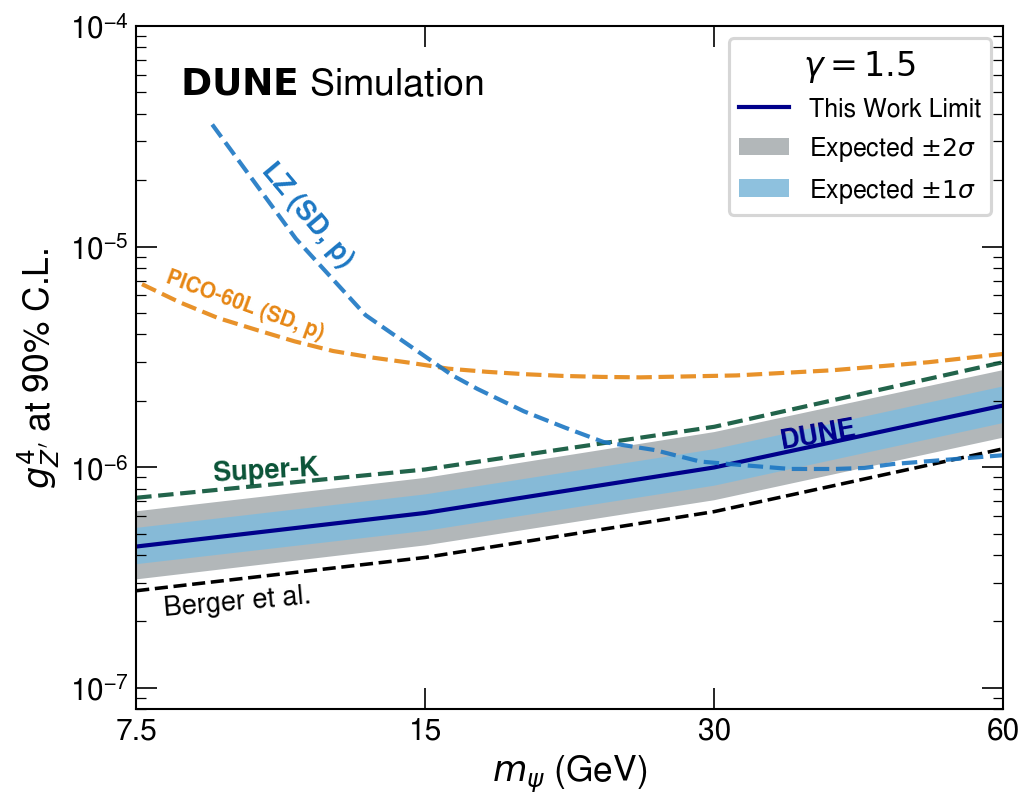

In [15]:

################################################################
#                 PLOT FIGURE          gamma = 1.5             #
################################################################
fig, ax = plt.subplots(figsize=(7.0, 5.5), dpi=150)

# Colors
c_pheno = "#4D4D4D"
c_pico = "#E68613"
c_lz = "#1C77C3"
sig2 = "#3F4B52"
sig1 = "#82BBDB"
sk = "#0A5337"

#plt.fill_between(m_p, gZ4_PICO, 1, alpha=0.3,label = 'PICO 60L, p', color = 'darkgreen')
# Lines
line_this, = ax.plot(MA[4:8], limits[2][4:8], lw=2., color='darkblue',ls='-', label = 'This Work Limit')
line_pheno, = ax.plot(MA[4:8], PhenPaperSensitivity[4:8], '--', lw=1.7, color='black')

plt.plot(MA[4:8], sk_b1p5,1., color=sk, alpha = 0.9,ls='--', lw=2)
plt.plot(m_p, gZ4_PICO,1., color=c_pico, alpha = 0.9,ls='--', lw=2)

plt.plot(mA_array, gZ4_LZ,1., color=c_lz, alpha = 0.9,ls = '--', lw=2)



# Bands
band_2s = ax.fill_between(
    MA[4:8], limits[0][4:8], limits[4][4:8],
    alpha=0.4, label=r'Expected $\pm 2\sigma$',color=sig2,ec=None
)
band_1s = ax.fill_between(
    MA[4:8], limits[1][4:8], limits[3][4:8],
    alpha=0.90, label=r'Expected $\pm 1\sigma$', color=sig1, ec=None
)


# ---- Axes ----
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(8e-8, 1e-4)
ax.set_xlim(7.5, 60)

ax.set_xlabel(r'$m_\psi$ (GeV)', fontsize=17)
ax.set_ylabel(r'$g_{Z^\prime}^4$ at 90% C.L.', fontsize=17)

# ---- Curve labels INSIDE plot ----
#ax.text(12, limits[2][1] * 1.10, "This Work", color=c_this, fontsize=14)
ax.text(35, PhenPaperSensitivity[0] * 2., "DUNE", color='darkblue', fontsize=13, rotation=10, fontweight='bold')
ax.text(8.0, PhenPaperSensitivity[0] * 0.35, "Berger et al.", color='black', fontsize=13, rotation=5)
ax.text(9.0, sk_b1p5[0] * 1.2, "Super-K", color=sk, fontsize=13, fontweight='bold', rotation=3)
ax.text(8, gZ4_PICO[10]*0.45 , "PICO-60L (SD, p)", color=c_pico, fontsize=10, fontweight='bold',rotation=-20)
ax.text(10, gZ4_LZ[1]*.75, "LZ (SD, p)", color=c_lz, fontsize=13, fontweight='bold', rotation=-50)

# disable ALL minor ticks on x axis
ax.xaxis.set_minor_locator(NullLocator())

# prevent Matplotlib from adding extra log ticks
ax.xaxis.set_major_locator(FixedLocator(MA[0:4]))

# avoid scientific notation on axis
ax.get_xaxis().set_major_formatter(ScalarFormatter())

ax.set_xticks(MA[4:8])
ax.set_xticklabels(['7.5','15','30','60'])

dunestyle.Simulation()
# ---- Legend only for bands ----
ax.legend(title = r'$\gamma = 1.5$', frameon=True, fontsize=12, loc="upper right", title_fontsize=16)

plt.tight_layout()
plt.savefig("plot_gamma1p5_v2_final.pdf")
plt.show()




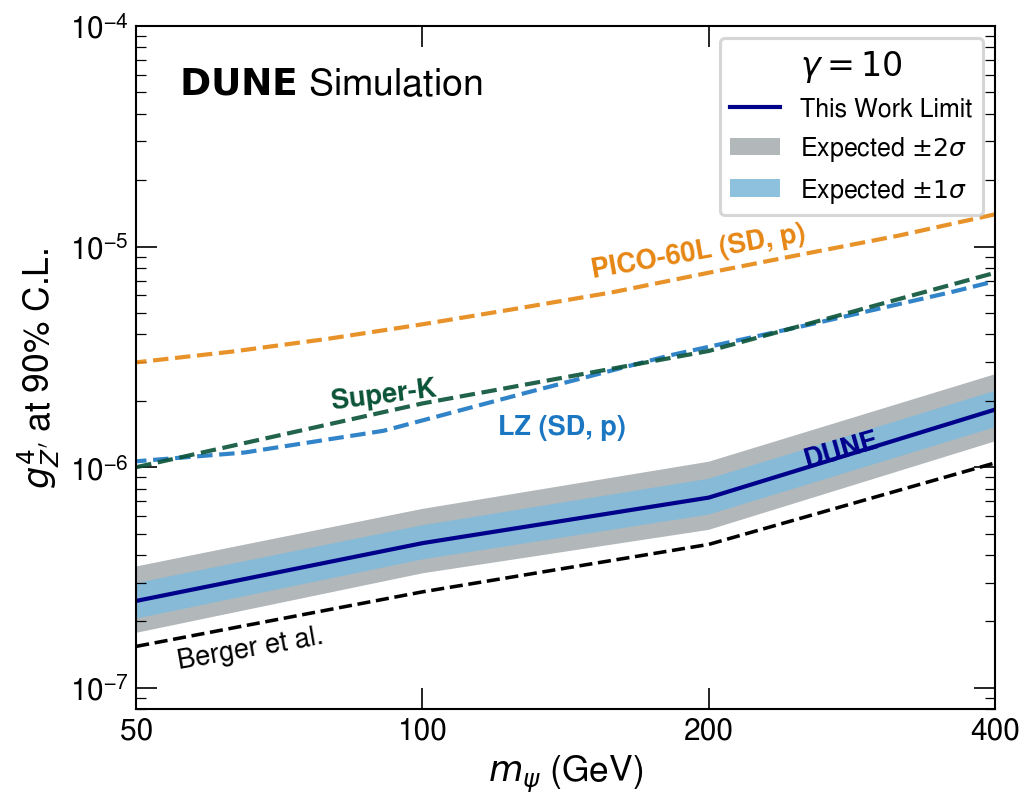

In [16]:
################################################################
#                 PLOT FIGURE          gamma = 10              #
################################################################
fig, ax = plt.subplots(figsize=(7.0, 5.5), dpi=150)

# Colors
c_pheno = "#4D4D4D"
c_pico = "#E68613"
c_lz = "#1C77C3"
sig2 = "#3F4B52"
sig1 = "#82BBDB"
sk = "#0A5337"

#plt.fill_between(m_p, gZ4_PICO, 1, alpha=0.3,label = 'PICO 60L, p', color = 'darkgreen')
# Lines
line_this, = ax.plot(MA[8:12], limits[2][8:12], lw=2., color='darkblue',ls='-', label = 'This Work Limit')
line_pheno, = ax.plot(MA[8:12], PhenPaperSensitivity[8:12], '--', lw=1.7, color='black')

plt.plot(mA_array, gZ4_LZ,lw=2., color=c_lz, ls = '--',alpha = 0.9)
plt.plot(MA[8:12], sk_b10,lw=2., color=sk, ls='--', alpha = 0.9)
plt.plot(m_p, gZ4_PICO,lw=2., color=c_pico, ls='--', alpha = 0.9)





# Bands
band_2s = ax.fill_between(
    MA[8:12], limits[0][8:12], limits[4][8:12],
    alpha=0.4, label=r'Expected $\pm 2\sigma$',color=sig2,ec=None
)
band_1s = ax.fill_between(
    MA[8:12], limits[1][8:12], limits[3][8:12],
    alpha=0.90, label=r'Expected $\pm 1\sigma$', color=sig1, ec=None
)


# ---- Axes ----
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(8e-8, 1e-4)
ax.set_xlim(50, 400)

ax.set_xlabel(r'$m_\psi$ (GeV)', fontsize=17)
ax.set_ylabel(r'$g_{Z^\prime}^4$ at 90% C.L.', fontsize=17)

# ---- Curve labels INSIDE plot ----
#ax.text(12, limits[2][1] * 1.10, "This Work", color=c_this, fontsize=14)
ax.text(250, PhenPaperSensitivity[0] * 1.65, "DUNE", color='darkblue', fontsize=13, rotation=16, fontweight='bold')
ax.text(55, PhenPaperSensitivity[0] * 0.2, "Berger et al.", color='black', fontsize=13, rotation=10)
ax.text(80, sk_b10[0] * 1.85, "Super-K", color=sk, fontsize=13, fontweight='bold',rotation=7)
ax.text(150, gZ4_PICO[10]*0.85, "PICO-60L (SD, p)", color=c_pico, fontsize=13, fontweight='bold', rotation = 10)
ax.text(120, gZ4_LZ[1]*0.13, "LZ (SD, p)", color=c_lz, fontsize=13, fontweight='bold')

# disable ALL minor ticks on x axis
ax.xaxis.set_minor_locator(NullLocator())

# prevent Matplotlib from adding extra log ticks
ax.xaxis.set_major_locator(FixedLocator(MA[8:12]))

# avoid scientific notation on axis
ax.get_xaxis().set_major_formatter(ScalarFormatter())

ax.set_xticks(MA[8:12])
ax.set_xticklabels(['50','100','200','400'])

dunestyle.Simulation()
# ---- Legend only for bands ----
ax.legend(title = r'$\gamma = 10$', frameon=True, fontsize=12, loc="upper right", title_fontsize=16)

plt.tight_layout()
plt.savefig("plot_gamma10_v2_final.pdf")
plt.show()




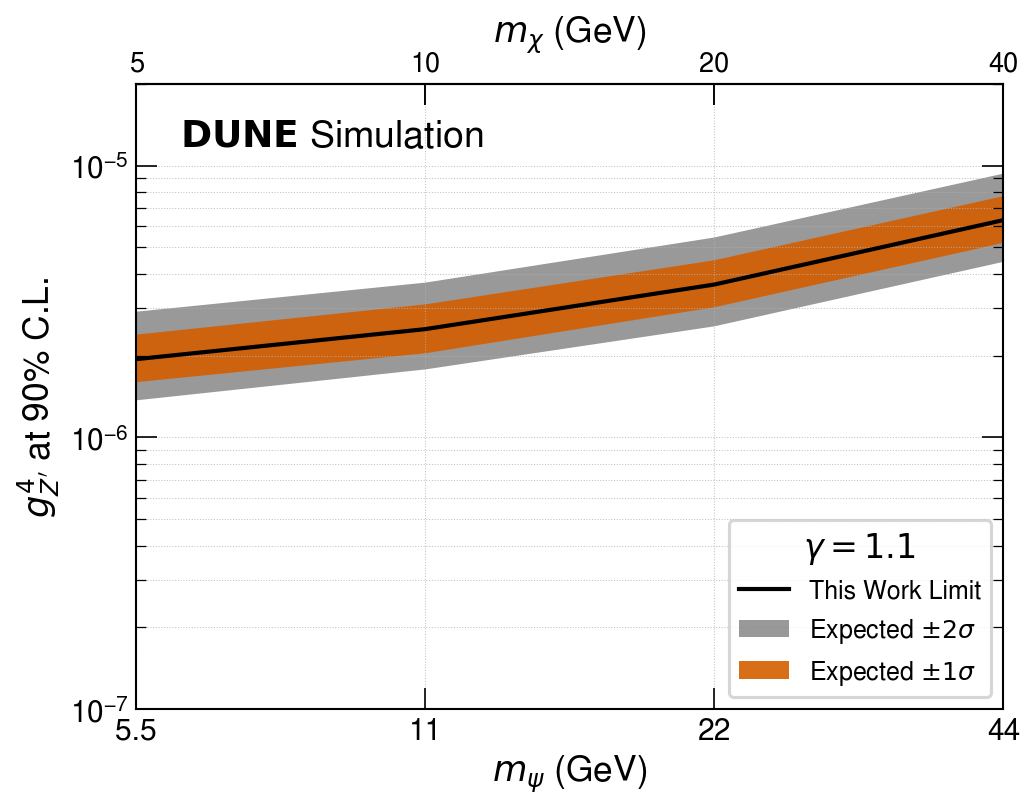

In [37]:

################################################################
#                 PLOT FIGURE          gamma = 1.1             #
################################################################

fig, ax = plt.subplots(figsize=(7.0, 5.5), dpi=150)

# Colors
c_pheno = "#4D4D4D"
c_pico = "#E68613"
c_lz = "#1C77C3"
sig2 = "#3F4B52"
sig1 = "#82BBDB"

#plt.fill_between(m_p, gZ4_PICO, 1, alpha=0.3,label = 'PICO 60L, p', color = 'darkgreen')
# Lines
line_this, = ax.plot(MA[0:4], limits[2][0:4], lw=2.,ls='-', label = 'This Work Limit')
#line_pheno, = ax.plot(MA[0:4], PhenPaperSensitivity[0:4], '--', lw=1.7, color='black')
#line_pico,  =
#ax.plot(m_p, gZ4_PICO, color=c_pico, ls='--', lw=2)
#line_lz,    = 
#ax.plot(mA_array, gZ4_LZ,1., color=c_lz, ls='--', lw=2)

# Bands
band_2s = ax.fill_between(
    MA[0:4], limits[0][0:4], limits[4][0:4],
    alpha=0.4, label=r'Expected $\pm 2\sigma$',ec=None
)
band_1s = ax.fill_between(
    MA[0:4], limits[1][0:4], limits[3][0:4],
    alpha=0.90, label=r'Expected $\pm 1\sigma$', ec=None
)

# ---- Axes ----
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-7, 2e-5)
ax.set_xlim(5.5, 44)

ax.set_xlabel(r'$m_\psi$ (GeV)', fontsize=17)
ax.set_ylabel(r'$g_{Z^\prime}^4$ at 90% C.L.', fontsize=17)

# ---- Curve labels INSIDE plot ----
#ax.text(12, limits[2][1] * 1.10, "This Work", color=c_this, fontsize=14)
#ax.text(25, PhenPaperSensitivity[0] * 10.5, "DUNE", color='darkblue', fontsize=13, rotation=8, fontweight='bold')
#ax.text(6.0, PhenPaperSensitivity[0] * 0.75, "Berger et al.", color='black', fontsize=13, rotation=5)
#ax.text(5.75, gZ4_PICO[10] * 0.8, "PICO-60L (SD, p)", color=c_pico, fontsize=10, fontweight='bold', rotation = -35)
#ax.text(9.5, gZ4_LZ[1]*1., "LZ (SD, p)", color=c_lz, fontsize=13,  fontweight='bold', rotation= -52)

# disable ALL minor ticks on x axis
ax.xaxis.set_minor_locator(NullLocator())
#ax.yaxis.set_minor_locator(NullLocator())

# prevent Matplotlib from adding extra log ticks
ax.xaxis.set_major_locator(FixedLocator(MA[0:4]))
#ax.yaxis.set_major_locator(FixedLocator(MA[0:4]))

# avoid scientific notation on axis
ax.get_xaxis().set_major_formatter(ScalarFormatter())
#ax.get_yaxis().set_major_formatter(ScalarFormatter())


ax.set_xticks(MA[0:4])
ax.set_xticklabels(['5.5','11','22','44'])


# ---- Upper axis: chi mass ----
ax_top = ax.secondary_xaxis("top")
ax_top.set_xscale("log")

ax_top.set_xticks(MA[0:4])
ax_top.set_xticklabels(["5", "10", "20", "40"])

ax_top.set_xlabel(r"$m_\chi$ (GeV)", fontsize=17)
ax_top.xaxis.set_minor_locator(NullLocator())
ax_top.tick_params(axis="x", labelsize=13)


"""
# ---- HARD FORCE y tick labels (no formatter involved) ----

yticks = [2e-6, 3e-6, 5e-6,8e-6]
ylabels = [ r"$2\times10^{-6}$", r"$3\times10^{-6}$",
           r"$5\times10^{-6}$", r"$8\times10^{-6}$"]

ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
"""
dunestyle.Simulation()
# ---- Legend only for bands ----
ax.legend(title = r'$\gamma = 1.1$', frameon=True, fontsize=12, loc="lower right", title_fontsize=16)
plt.grid(which="both", linestyle=":", alpha=0.8)
plt.tight_layout()
plt.savefig("clean_plot_gamma1p1_v2_final.pdf")
plt.show()


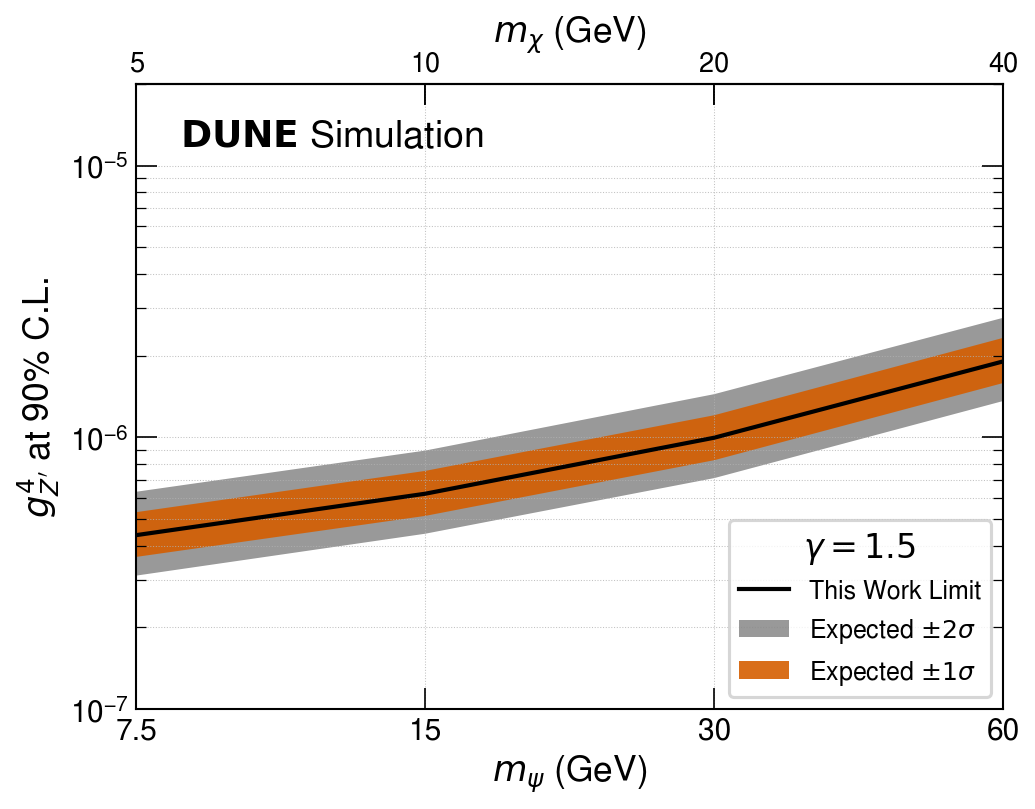

In [38]:
from matplotlib.ticker import LogLocator, LogFormatterSciNotation, NullFormatter
################################################################
#                 PLOT FIGURE          gamma = 1.5             #
################################################################
fig, ax = plt.subplots(figsize=(7.0, 5.5), dpi=150)

# Colors
c_pheno = "#4D4D4D"
c_pico = "#E68613"
c_lz = "#1C77C3"
sig2 = "#3F4B52"
sig1 = "#82BBDB"
sk = "#0A5337"

#plt.fill_between(m_p, gZ4_PICO, 1, alpha=0.3,label = 'PICO 60L, p', color = 'darkgreen')
# Lines
line_this, = ax.plot(MA[4:8], limits[2][4:8], lw=2.,ls='-', label = 'This Work Limit')
#line_pheno, = ax.plot(MA[4:8], PhenPaperSensitivity[4:8], '--', lw=1.7, color='black')

#plt.plot(MA[4:8], sk_b1p5,1., color=sk, alpha = 0.9,ls='--', lw=2)
#plt.plot(m_p, gZ4_PICO,1., color=c_pico, alpha = 0.9,ls='--', lw=2)

#plt.plot(mA_array, gZ4_LZ,1., color=c_lz, alpha = 0.9,ls = '--', lw=2)



# Bands
band_2s = ax.fill_between(
    MA[4:8], limits[0][4:8], limits[4][4:8],
    alpha=0.4, label=r'Expected $\pm 2\sigma$',ec=None
)
band_1s = ax.fill_between(
    MA[4:8], limits[1][4:8], limits[3][4:8],
    alpha=0.90, label=r'Expected $\pm 1\sigma$',ec=None
)


# ---- Axes ----
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-7, 2e-5)
ax.set_xlim(7.5, 60)

ax.set_xlabel(r'$m_\psi$ (GeV)', fontsize=17)
ax.set_ylabel(r'$g_{Z^\prime}^4$ at 90% C.L.', fontsize=17)

# ---- Curve labels INSIDE plot ----
#ax.text(12, limits[2][1] * 1.10, "This Work", color=c_this, fontsize=14)
#ax.text(35, PhenPaperSensitivity[0] * 2., "DUNE", color='black', fontsize=13, rotation=10, fontweight='bold')
#ax.text(8.0, PhenPaperSensitivity[0] * 0.35, "Berger et al.", color='black', fontsize=13, rotation=5)
#ax.text(9.0, sk_b1p5[0] * 1.2, "Super-K", color=sk, fontsize=13, fontweight='bold', rotation=3)
#ax.text(8, gZ4_PICO[10]*0.45 , "PICO-60L (SD, p)", color=c_pico, fontsize=10, fontweight='bold',rotation=-20)
#ax.text(10, gZ4_LZ[1]*.75, "LZ (SD, p)", color=c_lz, fontsize=13, fontweight='bold', rotation=-50)


# ---- Upper axis: chi mass ----
ax_top = ax.secondary_xaxis("top")
ax_top.set_xscale("log")

ax_top.set_xticks(MA[4:8])
ax_top.set_xticklabels(["5", "10", "20", "40"])

ax_top.set_xlabel(r"$m_\chi$ (GeV)", fontsize=17)
ax_top.xaxis.set_minor_locator(NullLocator())
ax_top.tick_params(axis="x", labelsize=13)



# ---- HARD FORCE y tick labels (no formatter involved) ----
"""
yticks = [3e-7, 6e-7, 1e-6, 2e-6]
ylabels = [ r"$3\times10^{-7}$", r"$6\times10^{-7}$",
           r"$10^{-6}$", r"$2\times10^{-6}$"]

ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
""" 

# disable ALL minor ticks on x axis
ax.xaxis.set_minor_locator(NullLocator())

# prevent Matplotlib from adding extra log ticks
ax.xaxis.set_major_locator(FixedLocator(MA[4:8]))

# avoid scientific notation on axis
ax.get_xaxis().set_major_formatter(ScalarFormatter())



ax.set_xticks(MA[4:8])
ax.set_xticklabels(['7.5','15','30','60'])

dunestyle.Simulation()

# ---- Legend only for bands ----
ax.legend(title = r'$\gamma = 1.5$', frameon=True, fontsize=12, loc="lower right", title_fontsize=16)
plt.grid(which="both", linestyle=":", alpha=0.8)
plt.tight_layout()
plt.savefig("clean_plot_gamma1p5_v2_final.pdf")
plt.show()




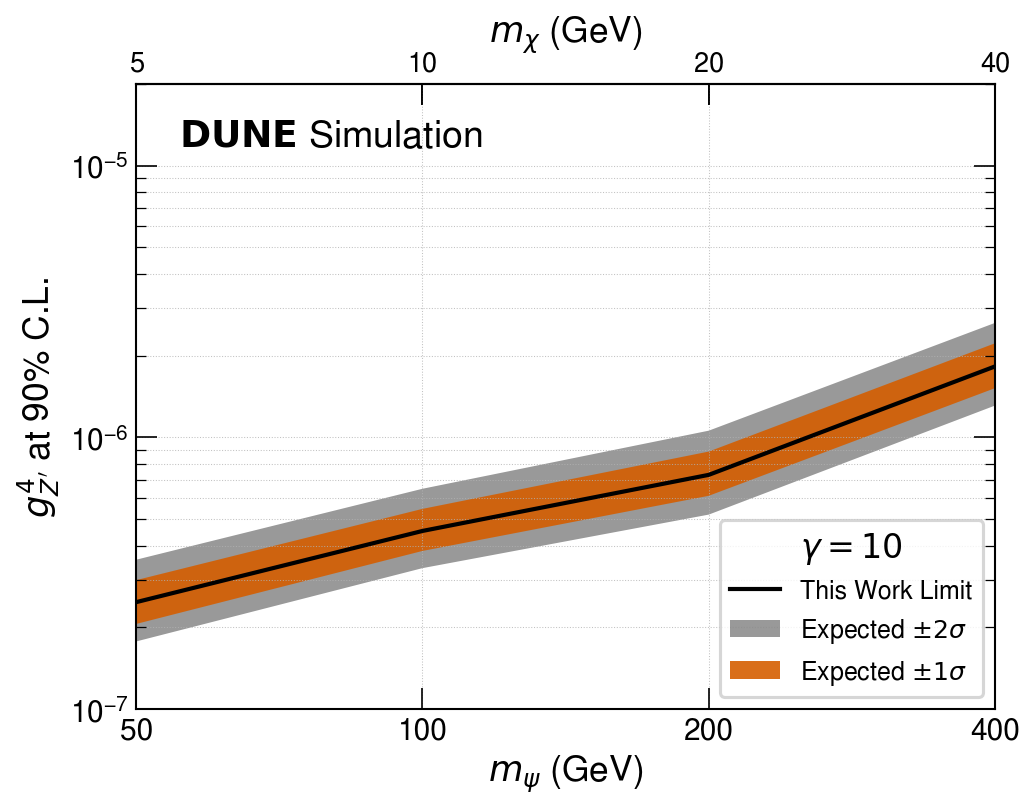

In [39]:
################################################################
#                 PLOT FIGURE          gamma = 10              #
################################################################
fig, ax = plt.subplots(figsize=(7.0, 5.5), dpi=150)

# Colors
c_pheno = "#4D4D4D"
c_pico = "#E68613"
c_lz = "#1C77C3"
sig2 = "#3F4B52"
sig1 = "#82BBDB"
sk = "#0A5337"

#plt.fill_between(m_p, gZ4_PICO, 1, alpha=0.3,label = 'PICO 60L, p', color = 'darkgreen')
# Lines
line_this, = ax.plot(MA[8:12], limits[2][8:12], lw=2.,ls='-', label = 'This Work Limit')
#line_pheno, = ax.plot(MA[8:12], PhenPaperSensitivity[8:12], '--', lw=1.7, color='black')
#
#plt.plot(mA_array, gZ4_LZ,lw=2., color=c_lz, ls = '--',alpha = 0.9)
#plt.plot(MA[8:12], sk_b10,lw=2., color=sk, ls='--', alpha = 0.9)
#plt.plot(m_p, gZ4_PICO,lw=2., color=c_pico, ls='--', alpha = 0.9)





# Bands
band_2s = ax.fill_between(
    MA[8:12], limits[0][8:12], limits[4][8:12],
    alpha=0.4, label=r'Expected $\pm 2\sigma$',ec=None
)
band_1s = ax.fill_between(
    MA[8:12], limits[1][8:12], limits[3][8:12],
    alpha=0.90, label=r'Expected $\pm 1\sigma$', ec=None
)


# ---- Axes ----
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-7, 2e-5)
ax.set_xlim(50, 400)

ax.set_xlabel(r'$m_\psi$ (GeV)', fontsize=17)
ax.set_ylabel(r'$g_{Z^\prime}^4$ at 90% C.L.', fontsize=17)

# ---- Curve labels INSIDE plot ----
#ax.text(12, limits[2][1] * 1.10, "This Work", color=c_this, fontsize=14)
#ax.text(250, PhenPaperSensitivity[0] * 1.65, "DUNE", color='black', fontsize=13, rotation=16, fontweight='bold')
#ax.text(55, PhenPaperSensitivity[0] * 0.2, "Berger et al.", color='black', fontsize=13, rotation=10)
#ax.text(80, sk_b10[0] * 1.85, "Super-K", color=sk, fontsize=13, fontweight='bold',rotation=7)
#ax.text(150, gZ4_PICO[10]*0.85, "PICO-60L (SD, p)", color=c_pico, fontsize=13, fontweight='bold', rotation = 10)
#ax.text(120, gZ4_LZ[1]*0.13, "LZ (SD, p)", color=c_lz, fontsize=13, fontweight='bold')

# disable ALL minor ticks on x axis
ax.xaxis.set_minor_locator(NullLocator())

# prevent Matplotlib from adding extra log ticks
ax.xaxis.set_major_locator(FixedLocator(MA[8:12]))

# avoid scientific notation on axis
ax.get_xaxis().set_major_formatter(ScalarFormatter())


# ---- HARD FORCE y tick labels (no formatter involved) ----
"""
yticks = [3e-7, 6e-7, 1e-6, 2e-6]
ylabels = [ r"$3\times10^{-7}$", r"$6\times10^{-7}$",
           r"$10^{-6}$", r"$2\times10^{-6}$"]

ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)

"""

# ---- Upper axis: chi mass ----
ax_top = ax.secondary_xaxis("top")
ax_top.set_xscale("log")

ax_top.set_xticks(MA[8:12])
ax_top.set_xticklabels(["5", "10", "20", "40"])

ax_top.set_xlabel(r"$m_\chi$ (GeV)", fontsize=17)
ax_top.xaxis.set_minor_locator(NullLocator())
ax_top.tick_params(axis="x", labelsize=13)


ax.set_xticks(MA[8:12])
ax.set_xticklabels(['50','100','200','400'])

dunestyle.Simulation()
# ---- Legend only for bands ----
ax.legend(title = r'$\gamma = 10$', frameon=True, fontsize=12, loc="lower right", title_fontsize=16)
plt.grid(which="both", linestyle=":", alpha=0.8)
plt.tight_layout()
plt.savefig("clean_plot_gamma10_v2_final.pdf")
plt.show()




### Plotting ($m_\psi$, $\gamma$) for each $m_\chi$ mass value

In [24]:
print(MB,MA)

[ 5 10 20 40] [  5.5  11.   22.   44.    7.5  15.   30.   60.   50.  100.  200.  400. ]


In [ ]:



line_this, = ax.plot(MA[8:12], limits[2][8:12], lw=2.,ls='-', label = 'This Work Limit')


# Bands
band_2s = ax.fill_between(
    MA[8:12], limits[0][8:12], limits[4][8:12],
    alpha=0.4, label=r'Expected $\pm 2\sigma$',ec=None
)
band_1s = ax.fill_between(
    MA[8:12], limits[1][8:12], limits[3][8:12],
    alpha=0.90, label=r'Expected $\pm 1\sigma$', ec=None
)
